In [47]:
import time, math, warnings, traceback

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
from sklearn.cluster import KMeans






In [48]:
df = pd.read_csv('Wine.csv')

df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [49]:
descriptor_cols = ['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
                   'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins',
                   'Color_Intensity', 'Hue', 'OD280', 'Proline']

# Phương án 1: Loại bỏ outliers
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean


a = int(input("Chọn phương án xử lý outliers (1: Loại bỏ outliers, 2: Giữ nguyên outliers): "))
if a == 1:

    df_cleaned = remove_outliers_iqr(df, descriptor_cols)
else: 
    df_cleaned = df.copy()
    print("Giữ nguyên dữ liệu ban đầu.")

# Lấy dữ liệu đã xử lý
X = df_cleaned[descriptor_cols].values

# Chuẩn hóa (Z-score standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dữ liệu sau chuẩn hóa:")
print(f"Mean: {X_scaled.mean(axis=0)}")  # Gần 0
print(f"Std: {X_scaled.std(axis=0)}")    # Gần 1

Giữ nguyên dữ liệu ban đầu.
Dữ liệu sau chuẩn hóa:
Mean: [-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17  0.00000000e+00 -3.99181312e-16  3.59263181e-16
 -1.19754394e-16  2.49488320e-17  1.99590656e-16  3.19345050e-16
 -1.59672525e-16]
Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [50]:
# Chuyển thành DataFrame để dễ xem
df_scaled = pd.DataFrame(X_scaled, 
                         columns=descriptor_cols,
                         index=df_cleaned.index)

print("="*80)
print("DỮ LIỆU SAU CHUẨN HÓA (DataFrame)")
print("="*80)
print(df_scaled)

print("\n" + "="*80)
print("5 DÒNG ĐẦU TIÊN")
print(df_scaled.head())


DỮ LIỆU SAU CHUẨN HÓA (DataFrame)
      Alcohol  Malic_Acid       Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    1.518613   -0.562250  0.232053     -1.169593   1.913905       0.808997   
1    0.246290   -0.499413 -0.827996     -2.490847   0.018145       0.568648   
2    0.196879    0.021231  1.109334     -0.268738   0.088358       0.808997   
3    1.691550   -0.346811  0.487926     -0.809251   0.930918       2.491446   
4    0.295700    0.227694  1.840403      0.451946   1.281985       0.808997   
..        ...         ...       ...           ...        ...            ...   
173  0.876275    2.974543  0.305159      0.301803  -0.332922      -0.985614   
174  0.493343    1.412609  0.414820      1.052516   0.158572      -0.793334   
175  0.332758    1.744744 -0.389355      0.151661   1.422412      -1.129824   
176  0.209232    0.227694  0.012732      0.151661   1.422412      -1.033684   
177  1.395086    1.583165  1.365208      1.502943  -0.262708      -0.392751   

     Flavanoids  

In [51]:
y_true = df['Customer_Segment']
print(y_true.value_counts())

Customer_Segment
2    71
1    59
3    48
Name: count, dtype: int64


In [52]:
df_1 = df_scaled.copy()
df_2 = df_scaled[['Alcohol','Flavanoids', 'Total_Phenols', 'Color_Intensity', 'OD280', 'Proline']].copy()
df_2.head()

,Alcohol,Flavanoids,Total_Phenols,Color_Intensity,OD280,Proline
0,1.518613,1.034819,0.808997,0.251717,1.847920,1.013009
1,0.246290,0.733629,0.568648,-0.293321,1.113449,0.965242
2,0.196879,1.215533,0.808997,0.269020,0.788587,1.395148
3,1.691550,1.466525,2.491446,1.186068,1.184071,2.334574
4,0.295700,0.663351,0.808997,-0.319276,0.449601,-0.037874


In [53]:
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU VÀ CÁC THAM SỐ

print(f"✓ df_2 shape: {df_2.shape} (6 features chọn lọc)")

# Chọn data để phân cụm 
X = df_2.values
N, p = X.shape

K_values = range(2, 8)

K = 3
# ---------------------

print(f"\n✓ Số mẫu (N): {N}")
print(f"✓ Số chiều (p): {p}")
print(f"✓ Dải số cụm sẽ được kiểm tra (K): {list(K_values)}")
print(f"✓ Ví dụ khởi tạo sẽ được thực hiện với K = {K}")



# BƯỚC 2: VÍ DỤ KHỞI TẠO THAM SỐ (với K đã chọn)
print(f"BƯỚC 2: VÍ DỤ KHỞI TẠO THAM SỐ (VỚI K = {K})")

np.random.seed(42)

# P_k: Xác suất tiên nghiệm (prior probabilities)
# Khởi tạo đồng đều cho K cụm
P = np.ones(K) / K
print(f"\n✓ P_k (xác suất tiên nghiệm):\n{P}")

# mu_k: Trung bình của mỗi cụm (mean vectors)
# Khởi tạo ngẫu nhiên từ dữ liệu
random_idx = np.random.choice(N, K, replace=False)
mu = X[random_idx]
print(f"\n✓ μ_k (trung bình các cụm):\n{mu}")

# Sigma_k: Ma trận hiệp phương sai của mỗi cụm (covariance matrices)
# Khởi tạo là ma trận đơn vị nhân với phương sai mẫu
sigma = [np.eye(p) * np.var(X) for _ in range(K)]
print(f"\n✓ Σ_k đã được khởi tạo (shape: {p}x{p} cho mỗi cụm)")



# BƯỚC 3: XÂY DỰNG HÀM F_MIX(x) - MẬT ĐỘ HỖN HỢP

print("BƯỚC 3: XÂY DỰNG HÀM F_MIX(x)")



def gaussian_pdf(x, mu, sigma):
    """Hàm mật độ xác suất Gaussian đa biến."""
    return multivariate_normal.pdf(x, mean=mu, cov=sigma, allow_singular=True)

def f_mix(x, P, mu, sigma, K):
    """Hàm mật độ hỗn hợp (Mixture density function)."""
    density = 0
    for k in range(K):
        density += P[k] * gaussian_pdf(x, mu[k], sigma[k])
    return density

# Kiểm tra hàm f_mix với một mẫu và các tham số đã khởi tạo
sample_density = f_mix(X[0], P, mu, sigma, K)
print(f"\n✓ Hàm F_mix đã được định nghĩa")
print(f"✓ Ví dụ: F_mix(x[0]) với K={K} là {sample_density:.6f}")

✓ df_2 shape: (178, 6) (6 features chọn lọc)

✓ Số mẫu (N): 178
✓ Số chiều (p): 6
✓ Dải số cụm sẽ được kiểm tra (K): [2, 3, 4, 5, 6, 7]
✓ Ví dụ khởi tạo sẽ được thực hiện với K = 3
BƯỚC 2: VÍ DỤ KHỞI TẠO THAM SỐ (VỚI K = 3)

✓ P_k (xác suất tiên nghiệm):
[0.33333333 0.33333333 0.33333333]

✓ μ_k (trung bình các cụm):
[[ 0.78980621  1.00469996  0.64876424  0.01812906  1.05695159  0.3124203 ]
 [ 1.49390724  0.6231926   0.88911397  0.07868886  1.01457831  1.06077633]
 [-0.08723191 -1.53533585 -1.20994036 -0.19815593 -0.42611337 -0.46778066]]

✓ Σ_k đã được khởi tạo (shape: 6x6 cho mỗi cụm)
BƯỚC 3: XÂY DỰNG HÀM F_MIX(x)

✓ Hàm F_mix đã được định nghĩa
✓ Ví dụ: F_mix(x[0]) với K=3 là 0.001422


Định nghĩa thuật toán EM

In [54]:
# BƯỚC 4: ĐỊNH NGHĨA HÀM E-STEP VỚI LOG-SPACE

print("BƯỚC 4: ĐỊNH NGHĨA HÀM E-STEP")

from scipy.special import logsumexp
from scipy.stats import multivariate_normal

def e_step_logspace(X, mu, Sigma_list, p_k):
    """
    E-step sử dụng log-space để tránh underflow.
    """
    N, p = X.shape
    K = len(Sigma_list)
    log_resp = np.zeros((N, K))
    
    for k in range(K):
        log_resp[:, k] = multivariate_normal.logpdf(
            X, mean=mu[k], cov=Sigma_list[k], allow_singular=True
        ) + np.log(p_k[k] + 1e-300)
    
    ll_per_obs = logsumexp(log_resp, axis=1)
    log_tau = log_resp - ll_per_obs[:, None]
    tau = np.exp(log_tau)
    ll = np.sum(ll_per_obs)
    
    return tau, ll, log_tau

print("\n✓ Hàm E-step (e_step_logspace) đã được định nghĩa.")

# BƯỚC 5: ĐỊNH NGHĨA HÀM M-STEP VỚI CÁC CẤU TRÚC COVARIANCE

print("BƯỚC 5: ĐỊNH NGHĨA HÀM M-STEP")

def m_step_updates(X, tau, cov_type='full', min_covar=1e-3):
    """
    M-step: Cập nhật tham số với các cấu trúc covariance khác nhau.
    """
    N, p = X.shape
    K = tau.shape[1]
    
    Nk = tau.sum(axis=0) + 1e-10
    p_k = Nk / N
    mu = (tau.T @ X) / Nk[:, None]
    
    Sigma_list = []
    
    if cov_type == 'spherical_equal':
        total_variance = 0
        for k in range(K):
            diff = X - mu[k]
            total_variance += np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2))
        variance = max(total_variance / (N * p), min_covar)
        Sigma_list = [np.eye(p) * variance for _ in range(K)]
        
    elif cov_type == 'spherical_varying':
        for k in range(K):
            diff = X - mu[k]
            variance_k = np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2)) / (Nk[k] * p)
            Sigma_list.append(np.eye(p) * max(variance_k, min_covar))
            
    elif cov_type == 'diagonal':
        for k in range(K):
            diff = X - mu[k]
            weighted_var = np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2), axis=0) / Nk[k]
            Sigma_list.append(np.diag(np.maximum(weighted_var, min_covar)))
            
    elif cov_type == 'full':
        for k in range(K):
            X_centered = X - mu[k]
            S = (tau[:, k][:, None] * X_centered).T @ X_centered / Nk[k]
            S += min_covar * np.eye(p)
            Sigma_list.append(S)
            
    else:
        raise ValueError(f"Unknown cov_type: {cov_type}")
    
    return p_k, mu, Sigma_list

print("\n✓ Hàm M-step (m_step_updates) đã được định nghĩa.")

# BƯỚC 6: ĐỊNH NGHĨA THUẬT TOÁN EM HOÀN CHỈNH
print("BƯỚC 6: ĐỊNH NGHĨA THUẬT TOÁN EM")


def em_algorithm(X, K, cov_type='full', max_iter=100, tol=1e-4, verbose=True):
    """
    Thuật toán EM để tối ưu GMM với các cấu trúc covariance.
    """
    N, p = X.shape
    np.random.seed(42) # Để đảm bảo tính nhất quán khi khởi tạo
    
    # Khởi tạo tham số
    P = np.ones(K) / K
    random_idx = np.random.choice(N, K, replace=False)
    mu = X[random_idx]
    
    if cov_type == 'spherical_equal' or cov_type == 'spherical_varying':
        sigma = [np.eye(p) * np.var(X) for _ in range(K)]
    elif cov_type == 'diagonal':
        sigma = [np.diag(np.var(X, axis=0)) for _ in range(K)]
    else: # full
        sigma = [np.cov(X.T) + np.eye(p) * 1e-3 for _ in range(K)]
    
    log_L_history = []
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        # E-STEP
        gamma, log_L, _ = e_step_logspace(X, mu, sigma, P)
        log_L_history.append(log_L)
        
        if verbose and iteration % 10 == 0:
            print(f"  Iteration {iteration}: Log-likelihood = {log_L:.4f}")
        
        if abs(log_L - prev_log_L) < tol and iteration > 0:
            if verbose:
                print(f"  ✓ Hội tụ tại iteration {iteration}")
            break
        prev_log_L = log_L
        
        # M-STEP
        P, mu, sigma = m_step_updates(X, gamma, cov_type=cov_type)
    
    return P, mu, sigma, gamma, log_L_history

print("\n✓ Hàm chính (em_algorithm) đã được định nghĩa.")
print("TẤT CẢ CÁC HÀM CẦN THIẾT ĐÃ SẴN SÀNG ĐỂ SỬ DỤNG.")

BƯỚC 4: ĐỊNH NGHĨA HÀM E-STEP

✓ Hàm E-step (e_step_logspace) đã được định nghĩa.
BƯỚC 5: ĐỊNH NGHĨA HÀM M-STEP

✓ Hàm M-step (m_step_updates) đã được định nghĩa.
BƯỚC 6: ĐỊNH NGHĨA THUẬT TOÁN EM

✓ Hàm chính (em_algorithm) đã được định nghĩa.
TẤT CẢ CÁC HÀM CẦN THIẾT ĐÃ SẴN SÀNG ĐỂ SỬ DỤNG.


CHẠY THỬ NGHIỆM VÀ HIỂN THỊ SỰ THAY ĐỔI CỦA LOG-LIKEHOOD THEO SỐ CỤM 


--- Đang chạy thuật toán cho K = 2 (cấu trúc: full) ---
✓ Hoàn thành K = 2:
  - Log-Likelihood cuối cùng: -1054.6588
  - Hội tụ sau 55 vòng lặp.

--- Đang chạy thuật toán cho K = 3 (cấu trúc: full) ---
✓ Hoàn thành K = 3:
  - Log-Likelihood cuối cùng: -888.3888
  - Hội tụ sau 28 vòng lặp.

--- Đang chạy thuật toán cho K = 4 (cấu trúc: full) ---
✓ Hoàn thành K = 4:
  - Log-Likelihood cuối cùng: -864.0159
  - Hội tụ sau 52 vòng lặp.

--- Đang chạy thuật toán cho K = 5 (cấu trúc: full) ---
✓ Hoàn thành K = 5:
  - Log-Likelihood cuối cùng: -825.9264
  - Hội tụ sau 40 vòng lặp.

--- Đang chạy thuật toán cho K = 6 (cấu trúc: full) ---
✓ Hoàn thành K = 6:
  - Log-Likelihood cuối cùng: -837.7714
  - Hội tụ sau 75 vòng lặp.

--- Đang chạy thuật toán cho K = 7 (cấu trúc: full) ---
✓ Hoàn thành K = 7:
  - Log-Likelihood cuối cùng: -801.7873
  - Hội tụ sau 78 vòng lặp.
BƯỚC 8: TRỰC QUAN HÓA SỰ THAY ĐỔI CỦA LOG-LIKELIHOOD THEO K


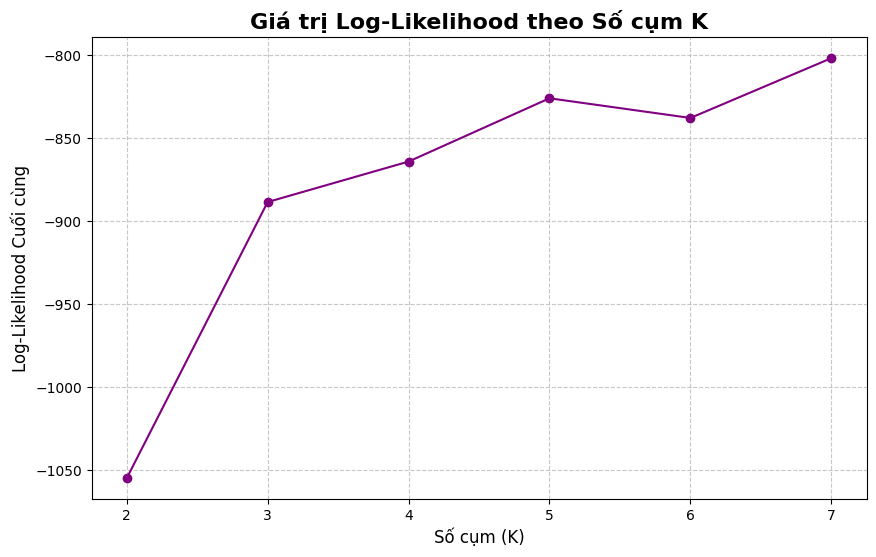


 nhận xét: Có thể thấy rằng log-likelihood luôn có xu hướng tăng khi K tăng.
Điều này là tự nhiên vì mô hình phức tạp hơn sẽ luôn 'khớp' (fit) với dữ liệu tốt hơn.
Đây là lý do chúng ta cần các tiêu chí như BIC/AIC ở bước tiếp theo để phạt sự phức tạp này và tìm ra K tối ưu.


In [55]:
# BƯỚC 7: CHẠY THỬ NGHIỆM VÀ SO SÁNH LOG-LIKELIHOOD


# Dải giá trị K cần kiểm tra
k_values = range(2, 8)
final_log_likelihoods = {} # Dùng dictionary để lưu K và kết quả tương ứng

# Chọn một cấu trúc covariance để thử nghiệm, ví dụ: 'full'
covariance_type_to_test = 'full'



for k in k_values:
    print(f"\n--- Đang chạy thuật toán cho K = {k} (cấu trúc: {covariance_type_to_test}) ---")
    
    # Chạy thuật toán EM cho giá trị k hiện tại
    # Tắt 'verbose' để output của vòng lặp gọn gàng hơn
    _, _, _, _, log_L_history = em_algorithm(
        X, 
        K=k, 
        cov_type=covariance_type_to_test, 
        verbose=False
    )
    
    # Lấy giá trị log-likelihood cuối cùng (giá trị hội tụ)
    final_log_L = log_L_history[-1]
    final_log_likelihoods[k] = final_log_L
    
    print(f"✓ Hoàn thành K = {k}:")
    print(f"  - Log-Likelihood cuối cùng: {final_log_L:.4f}")
    print(f"  - Hội tụ sau {len(log_L_history)} vòng lặp.")


# BƯỚC 8: TRỰC QUAN HÓA KẾT QUẢ LOG-LIKELIHOOD

print("BƯỚC 8: TRỰC QUAN HÓA SỰ THAY ĐỔI CỦA LOG-LIKELIHOOD THEO K")

# Chuyển dictionary sang list để vẽ
k_list = list(final_log_likelihoods.keys())
log_L_list = list(final_log_likelihoods.values())

plt.figure(figsize=(10, 6))
plt.plot(k_list, log_L_list, marker='o', linestyle='-', color='purple')
plt.title('Giá trị Log-Likelihood theo Số cụm K', fontsize=16, fontweight='bold')
plt.xlabel('Số cụm (K)', fontsize=12)
plt.ylabel('Log-Likelihood Cuối cùng', fontsize=12)
plt.xticks(k_list)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n nhận xét: Có thể thấy rằng log-likelihood luôn có xu hướng tăng khi K tăng.")
print("Điều này là tự nhiên vì mô hình phức tạp hơn sẽ luôn 'khớp' (fit) với dữ liệu tốt hơn.")
print("Đây là lý do chúng ta cần các tiêu chí như BIC/AIC ở bước tiếp theo để phạt sự phức tạp này và tìm ra K tối ưu.")

TỐI ƯU MÔ HÌNH 

1. Định nghĩa các cấu trúc của ma trận hiệp phương sai

In [56]:
# CÁC CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI 

print("CÁC CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI (ĐÃ CHUẨN HÓA CÔNG THỨC)")


covariance_structures = {
    'spherical_equal': {
        'name': 'EII (Spherical, Equal Volume)',
        'description': 'Tất cả cụm có cùng phương sai, hình cầu.',
        # #cov_params = 1 (chỉ một giá trị phương sai)
        'n_params_formula': '(K - 1) + (K * p) + 1'
    },
    'spherical_varying': {
        'name': 'VII (Spherical, Variable Volume)',
        'description': 'Mỗi cụm có phương sai khác nhau, hình cầu.',
        # #cov_params = K (mỗi cụm một giá trị phương sai)
        'n_params_formula': '(K - 1) + (K * p) + K'
    },
    'diagonal': {
        'name': 'VVI (Diagonal, Variable Volume & Shape)',
        'description': 'Mỗi cụm có ma trận hiệp phương sai chéo riêng.',
        # #cov_params = K * p (mỗi cụm có p phương sai trên đường chéo)
        'n_params_formula': '(K - 1) + (K * p) + (K * p)'
    },
    'full': {
        'name': 'VVV (Ellipsoidal, Unrestricted)',
        'description': 'Mỗi cụm có ma trận hiệp phương sai đầy đủ riêng.',
        # #cov_params = K * p * (p+1)/2
        'n_params_formula': '(K - 1) + (K * p) + (K * p * (p + 1) / 2)'
    }
}

for key, info in covariance_structures.items():
    print(f"\n{key.upper()}:")
    print(f"  • Tên mô hình: {info['name']}")
    print(f"  • Mô tả: {info['description']}")
    print(f"  • Công thức tính tham số M: {info['n_params_formula']}")

CÁC CẤU TRÚC MA TRẬN HIỆP PHƯƠNG SAI (ĐÃ CHUẨN HÓA CÔNG THỨC)

SPHERICAL_EQUAL:
  • Tên mô hình: EII (Spherical, Equal Volume)
  • Mô tả: Tất cả cụm có cùng phương sai, hình cầu.
  • Công thức tính tham số M: (K - 1) + (K * p) + 1

SPHERICAL_VARYING:
  • Tên mô hình: VII (Spherical, Variable Volume)
  • Mô tả: Mỗi cụm có phương sai khác nhau, hình cầu.
  • Công thức tính tham số M: (K - 1) + (K * p) + K

DIAGONAL:
  • Tên mô hình: VVI (Diagonal, Variable Volume & Shape)
  • Mô tả: Mỗi cụm có ma trận hiệp phương sai chéo riêng.
  • Công thức tính tham số M: (K - 1) + (K * p) + (K * p)

FULL:
  • Tên mô hình: VVV (Ellipsoidal, Unrestricted)
  • Mô tả: Mỗi cụm có ma trận hiệp phương sai đầy đủ riêng.
  • Công thức tính tham số M: (K - 1) + (K * p) + (K * p * (p + 1) / 2)


2. Định nghĩa các hàm tính số lượng tham số, các tiêu chí tối ưu BIC, AIC, ICL và đảm bảo ma trận hiệp phương sai ổn định về mặt số học

In [57]:
# HÀM TÍNH SỐ THAM SỐ

def count_parameters(K, p, cov_type):
    """
    Trả về số tham số toàn phần M cho mô hình GMM với K components, chiều p,
    và cấu trúc covariance 'cov_type' (chuẩn theo mclust-like codes).
    K: int, p: int, cov_type: str (one of 'EII','VII','EEI','VVI','EEE','VVV','VEI','EVI','VEE','EVE')
    """
    # mixing proportions: K-1
    mix = max(K - 1, 0)
    # means: K * p
    means = K * p

    cov_params = None
    ct = cov_type.lower()
    if ct in ('eii','spherical_equal'):
        # Equal volume, spherical: one variance shared
        cov_params = 1
    elif ct in ('vii','spherical_varying'):
        # Variable volume, spherical: one variance per component
        cov_params = K
    elif ct in ('eei','diagonal_equal'):
        # Equal volume, equal shape, diagonal: p parameters (common diagonal)
        cov_params = p
    elif ct in ('vvi','diagonal_varying'):
        # Variable volume, variable shape, diagonal: K * p
        cov_params = K * p
    elif ct in ('eee','full_equal'):
        # Equal volume, equal shape, equal orientation: common full covariance
        cov_params = p * (p + 1) // 2
    elif ct in ('vvv','full_varying'):
        # Full, each component has full covariance
        cov_params = K * p * (p + 1) // 2
    elif ct in ('vei',):
        # Variable volume, equal shape, diagonal orientation - approx:
        cov_params = K + (p - 1)
    elif ct in ('evi',):
        cov_params = 1 + K * (p - 1)
    elif ct in ('vee','v e e','v e e'.replace(' ','').lower()):
        cov_params = K + p*(p-1)//2
    else:
        # fallback: assume full per component
        cov_params = K * p * (p + 1) // 2

    M = mix + means + cov_params
    return M


# ============================================================
# CẬP NHẬT: HÀM TÍNH CHỈ SỐ ĐÁNH GIÁ (Lower is Better)
# ============================================================
def compute_aic_bic_icl(log_likelihood, N, M, gamma):
    """
    Tính AIC, BIC, ICL.
    Quy ước: Giá trị càng NHỎ càng TỐT.
    
    Parameters:
    - log_likelihood: Log-likelihood tại điểm hội tụ (thường là số âm)
    - N: Số lượng mẫu dữ liệu
    - M: Số lượng tham số của mô hình
    - gamma: Ma trận trách nhiệm (N x K) - Responsibility matrix
    """
    # Xử lý gamma để tránh lỗi log(0)
    gamma_safe = np.clip(gamma, 1e-30, 1.0) 
    
    # 1. Thành phần độ khớp (-2lnL)
    neg2ll = -2.0 * log_likelihood
    
    # 2. Tính AIC
    # AIC = -2lnL + 2M
    aic = neg2ll + 2.0 * M
    
    # 3. Tính BIC
    # BIC = -2lnL + M*ln(N)
    bic = neg2ll + M * np.log(N)
    
    # 4. Tính ICL
    # Entropy = tống(gamma * ln(gamma)). Giá trị này luôn ÂM.
    # ICL = BIC - 2 * Entropy
    # Vì Entropy âm, nên trừ đi 2*Entropy tương đương với việc CỘNG thêm một hình phạt dương.
    # Cụm càng mờ nhạt -> Entropy càng âm (lớn về trị tuyệt đối) -> ICL càng cao (xấu).
    entropy = np.sum(gamma_safe * np.log(gamma_safe))
    icl = bic - 2.0 * entropy
    
    return aic, bic, icl

    
def relabel_by_weight(p_k, mu, Sigma_list):
    """
    Sắp lại thứ tự các component theo p_k giảm dần.
    Trả về p_k_new, mu_new, Sigma_list_new.
    """
    order = np.argsort(-np.array(p_k))  # descending
    p_k_new = np.array(p_k)[order]
    mu_new = np.array(mu)[order]
    Sigma_new = [Sigma_list[i] for i in order]
    return p_k_new, mu_new, Sigma_new


def ensure_well_conditioned(Sigma, min_covar=1e-6, cond_thresh=1e12):
    """
    Đảm bảo ma trận hiệp phương sai Sigma tốt về mặt số học.
    Trả về ma trận đã điều chỉnh.
    """
    p = Sigma.shape[0]
    S = Sigma + min_covar * np.eye(p)
    try:
        cond = np.linalg.cond(S)
    except np.linalg.LinAlgError:
        cond = np.inf
    if cond > cond_thresh:
        # tăng regularization tỉ lệ để giảm condition number
        factor = cond / cond_thresh
        S += (min_covar * factor) * np.eye(p)
    return S


print("\n✓ Hàm count_parameters, compute_aic_bic_icl, relabel_by_weight và ensure_well_conditioned đã được định nghĩa")


✓ Hàm count_parameters, compute_aic_bic_icl, relabel_by_weight và ensure_well_conditioned đã được định nghĩa


3. Định nghĩa thuật toán EM với phiên bản tối ưu cho từng cấu trúc của ma trận hiệp phương sai được định nghĩa ở trên 



In [58]:
# BƯỚC AA: ĐỊNH NGHĨA THUẬT TOÁN EM PHÙ HỢP

# M-STEP VỚI CONSTRAINT

print("M-STEP VỚI CONSTRAINT")

    
def m_step_with_constraint(X, tau, cov_type='full', min_covar=1e-3):
    """
    M-step với ràng buộc cấu trúc covariance
    """
    N, p = X.shape
    K = tau.shape[1]
    
    N_k = tau.sum(axis=0) + 1e-10
    p_k = N_k / N
    mu = np.dot(tau.T, X) / N_k[:, None]
    
    Sigma_list = []
    
    if cov_type == 'spherical_equal':
        total_variance = 0
        for k in range(K):
            diff = X - mu[k]
            total_variance += np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2))
        variance = total_variance / (N * p)
        variance = max(variance, min_covar)
        Sigma_list = [np.eye(p) * variance for _ in range(K)]
        
    elif cov_type == 'spherical_varying':
        for k in range(K):
            diff = X - mu[k]
            variance_k = np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2)) / (N_k[k] * p)
            variance_k = max(variance_k, min_covar)
            Sigma_list.append(np.eye(p) * variance_k)
            
    elif cov_type == 'diagonal':
        for k in range(K):
            diff = X - mu[k]
            weighted_var = np.sum(tau[:, k].reshape(-1, 1) * (diff ** 2), axis=0) / N_k[k]
            weighted_var = np.clip(weighted_var, min_covar, None)
            Sigma_list.append(np.diag(weighted_var))
            
    else:  # full
        for k in range(K):
            diff = X - mu[k]
            weighted_diff = tau[:, k].reshape(-1, 1) * diff
            S_raw = (weighted_diff.T @ diff) / N_k[k] # Tính ma trận S "thô"
            
            S_stable = ensure_well_conditioned(S_raw, min_covar=min_covar, cond_thresh=1e12)
            
            Sigma_list.append(S_stable)
    
    return p_k, mu, Sigma_list

print("\n✓ Hàm m_step_with_constraint đã được định nghĩa")


# THUẬT TOÁN EM CHO TỪNG CẤU TRÚC COVARIANCE

print("THUẬT TOÁN EM CHO TỪNG CẤU TRÚC COVARIANCE")


def em_with_cov_structure(X, K, cov_type='full', max_iter=100, tol=1e-4, verbose=False):
    """
    EM algorithm với ràng buộc cấu trúc covariance
    """
    N, p = X.shape
    np.random.seed(42)
    
    P = np.ones(K) / K
    random_idx = np.random.choice(N, K, replace=False)
    mu = X[random_idx]
    
    if cov_type == 'spherical_equal':
        variance = np.var(X)
        sigma = [np.eye(p) * variance for _ in range(K)]
    elif cov_type == 'spherical_varying':
        sigma = [np.eye(p) * np.var(X) for _ in range(K)]
    elif cov_type == 'diagonal':
        sigma = [np.diag(np.var(X, axis=0)) for _ in range(K)]
    else:  # full
        sigma = [np.cov(X.T) + np.eye(p) * 1e-3 for _ in range(K)]
    
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        gamma, log_L, log_tau = e_step_logspace(X, mu, sigma, P)
        
        if verbose and iteration % 25 == 0:
            print(f"    Iteration {iteration}: Log-likelihood = {log_L:.4f}")
        
        if iteration > 0:
            if log_L < prev_log_L - 1e-6:
                import warnings
                warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
            
            if abs(log_L - prev_log_L) < tol:
                if verbose:
                    print(f"    ✓ Hội tụ tại iteration {iteration}")
                break
        
        prev_log_L = log_L
        P, mu, sigma = m_step_with_constraint(X, gamma, cov_type=cov_type)
    
    return P, mu, sigma, gamma, log_L

print("\n✓ Hàm em_with_cov_structure đã được định nghĩa")



M-STEP VỚI CONSTRAINT

✓ Hàm m_step_with_constraint đã được định nghĩa
THUẬT TOÁN EM CHO TỪNG CẤU TRÚC COVARIANCE

✓ Hàm em_with_cov_structure đã được định nghĩa


4. Thực hiện Grid Search để tìm ra cấu trúc của ma trận hiệp phương sai và số cụm là tốt nhất

In [59]:
# BƯỚC AB: GRID SEARCH - CHẠY THUẬT TOÁN VÀ THU THẬP KẾT QUẢ

K_range = range(2, 6)  
cov_types = ['spherical_equal', 'spherical_varying', 'diagonal', 'full']
results = []
N, p = X.shape

print("\n" + "=" * 80)
print("BẮT ĐẦU QUÁ TRÌNH GRID SEARCH (CHỈ TÍNH TOÁN)")
print("=" * 80)
print(f"• Số cụm K sẽ được thử nghiệm: {list(K_range)}")
print(f"• Các cấu trúc covariance: {len(cov_types)} loại")
print(f"• Tổng số mô hình sẽ được huấn luyện: {len(K_range) * len(cov_types)}")

start_time = time.time()
try:
    for K in K_range:
        for cov_type in cov_types:
            print(f"\n🔄 Đang chạy: K={K}, Cấu trúc='{cov_type}'...")
            
            try:
                # 1. Chạy thuật toán EM
                P, mu, sigma, gamma, log_L = em_with_cov_structure(
                    X, K, cov_type=cov_type, max_iter=150, tol=1e-4, verbose=False
                )
                
                # 2. Tính số tham số và các tiêu chí
                n_params = count_parameters(K, p, cov_type)
                aic, bic, icl = compute_aic_bic_icl(log_L, N, n_params, gamma)
                
                # 3. Lưu trữ kết quả
                results.append({
                    'K': K,
                    'Cov_Type': cov_type,
                    'Cov_Name': covariance_structures[cov_type]['name'],
                    'Log_Likelihood': log_L,
                    'N_Params': n_params,
                    'AIC': aic,
                    'BIC': bic,
                    'ICL': icl,
                    'Model': (P, mu, sigma, gamma) # Lưu lại các tham số của mô hình
                })
                
                print(f"  ✓ Kết quả: BIC={bic:8.2f}, LogL={log_L:8.2f}, Params={n_params}")
                
            except Exception as e:
                print(f"  ✗ LỖI khi chạy mô hình: {str(e)}")
                
    if len(results) == 0:
        raise ValueError("Không có mô hình nào chạy thành công!")
        
    # Tạo và sắp xếp DataFrame kết quả
    results_df = pd.DataFrame(results).sort_values('BIC', ascending=True)
    
    print(f"\n\n✓✓✓ HOÀN THÀNH QUÁ TRÌNH TÍNH TOÁN GRID SEARCH sau {time.time() - start_time:.2f} giây.")
    print("DataFrame 'results_df' đã được tạo và sẵn sàng để phân tích.")
    
except Exception as e:
    print(f"\n❌ LỖI NGHIÊM TRỌNG TRONG QUÁ TRÌNH GRID SEARCH: {str(e)}")
    traceback.print_exc()


BẮT ĐẦU QUÁ TRÌNH GRID SEARCH (CHỈ TÍNH TOÁN)
• Số cụm K sẽ được thử nghiệm: [2, 3, 4, 5]
• Các cấu trúc covariance: 4 loại
• Tổng số mô hình sẽ được huấn luyện: 16

🔄 Đang chạy: K=2, Cấu trúc='spherical_equal'...
  ✓ Kết quả: BIC= 2779.08, LogL=-1353.27, Params=14

🔄 Đang chạy: K=2, Cấu trúc='spherical_varying'...
  ✓ Kết quả: BIC= 2716.33, LogL=-1319.30, Params=15

🔄 Đang chạy: K=2, Cấu trúc='diagonal'...
  ✓ Kết quả: BIC= 2811.70, LogL=-1263.35, Params=55

🔄 Đang chạy: K=2, Cấu trúc='full'...
  ✓ Kết quả: BIC= 2394.32, LogL=-1054.66, Params=55

🔄 Đang chạy: K=3, Cấu trúc='spherical_equal'...
  ✓ Kết quả: BIC= 2399.71, LogL=-1145.45, Params=21

🔄 Đang chạy: K=3, Cấu trúc='spherical_varying'...
  ✓ Kết quả: BIC= 2404.34, LogL=-1142.58, Params=23

🔄 Đang chạy: K=3, Cấu trúc='diagonal'...
  ✓ Kết quả: BIC= 2526.15, LogL=-1048.03, Params=83

🔄 Đang chạy: K=3, Cấu trúc='full'...
  ✓ Kết quả: BIC= 2206.87, LogL= -888.39, Params=83

🔄 Đang chạy: K=4, Cấu trúc='spherical_equal'...
  ✓ Kết q

C:\Users\PC\AppData\Local\Temp\ipykernel_8380\3050480404.py:96: UserWarning: ⚠️ Log-likelihood giảm: -864.0127 → -864.0129
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_8380\3050480404.py:96: UserWarning: ⚠️ Log-likelihood giảm: -864.0129 → -864.0133
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_8380\3050480404.py:96: UserWarning: ⚠️ Log-likelihood giảm: -864.0133 → -864.0136
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_8380\3050480404.py:96: UserWarning: ⚠️ Log-likelihood giảm: -864.0136 → -864.0140
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\PC\AppData\Local\Temp\ipykernel_8380\3050480404.py:96: UserWarning: ⚠️ Log-likelihood giảm: -864.0140 → -864.0143
  warnings.warn(f"⚠️ Log-likelihood giảm: {prev_log_L:.4f} → {log_L:.4f}")
C:\Users\P

  ✓ Kết quả: BIC= 2303.21, LogL= -864.02, Params=111

🔄 Đang chạy: K=5, Cấu trúc='spherical_equal'...
  ✓ Kết quả: BIC= 2340.37, LogL=-1079.50, Params=35

🔄 Đang chạy: K=5, Cấu trúc='spherical_varying'...
  ✓ Kết quả: BIC= 2336.79, LogL=-1067.35, Params=39

🔄 Đang chạy: K=5, Cấu trúc='diagonal'...
  ✓ Kết quả: BIC= 2664.16, LogL= -971.94, Params=139

🔄 Đang chạy: K=5, Cấu trúc='full'...
  ✓ Kết quả: BIC= 2372.12, LogL= -825.93, Params=139


✓✓✓ HOÀN THÀNH QUÁ TRÌNH TÍNH TOÁN GRID SEARCH sau 0.41 giây.
DataFrame 'results_df' đã được tạo và sẵn sàng để phân tích.



KẾT QUẢ TỐI ƯU HÓA

📊 Bảng xếp hạng tất cả các mô hình (sắp xếp theo BIC - thấp hơn là tốt hơn):
 K          Cov_Type     BIC     AIC     ICL  Log_Likelihood  N_Params
 3              full 2206.87 1942.78 2219.13         -888.39        83
 4              full 2303.21 1950.03 2327.51         -864.02       111
 5 spherical_varying 2336.79 2212.70 2386.45        -1067.35        39
 5   spherical_equal 2340.37 2229.01 2398.40        -1079.50        35
 5              full 2372.12 1929.85 2398.64         -825.93       139
 4 spherical_varying 2379.52 2280.88 2409.88        -1109.44        31
 4   spherical_equal 2379.54 2290.45 2423.01        -1117.23        28
 2              full 2394.32 2219.32 2416.04        -1054.66        55
 3   spherical_equal 2399.71 2332.89 2420.15        -1145.45        21
 3 spherical_varying 2404.34 2331.16 2424.07        -1142.58        23
 3          diagonal 2526.15 2262.06 2536.69        -1048.03        83
 4          diagonal 2581.95 2228.77 2604.92      

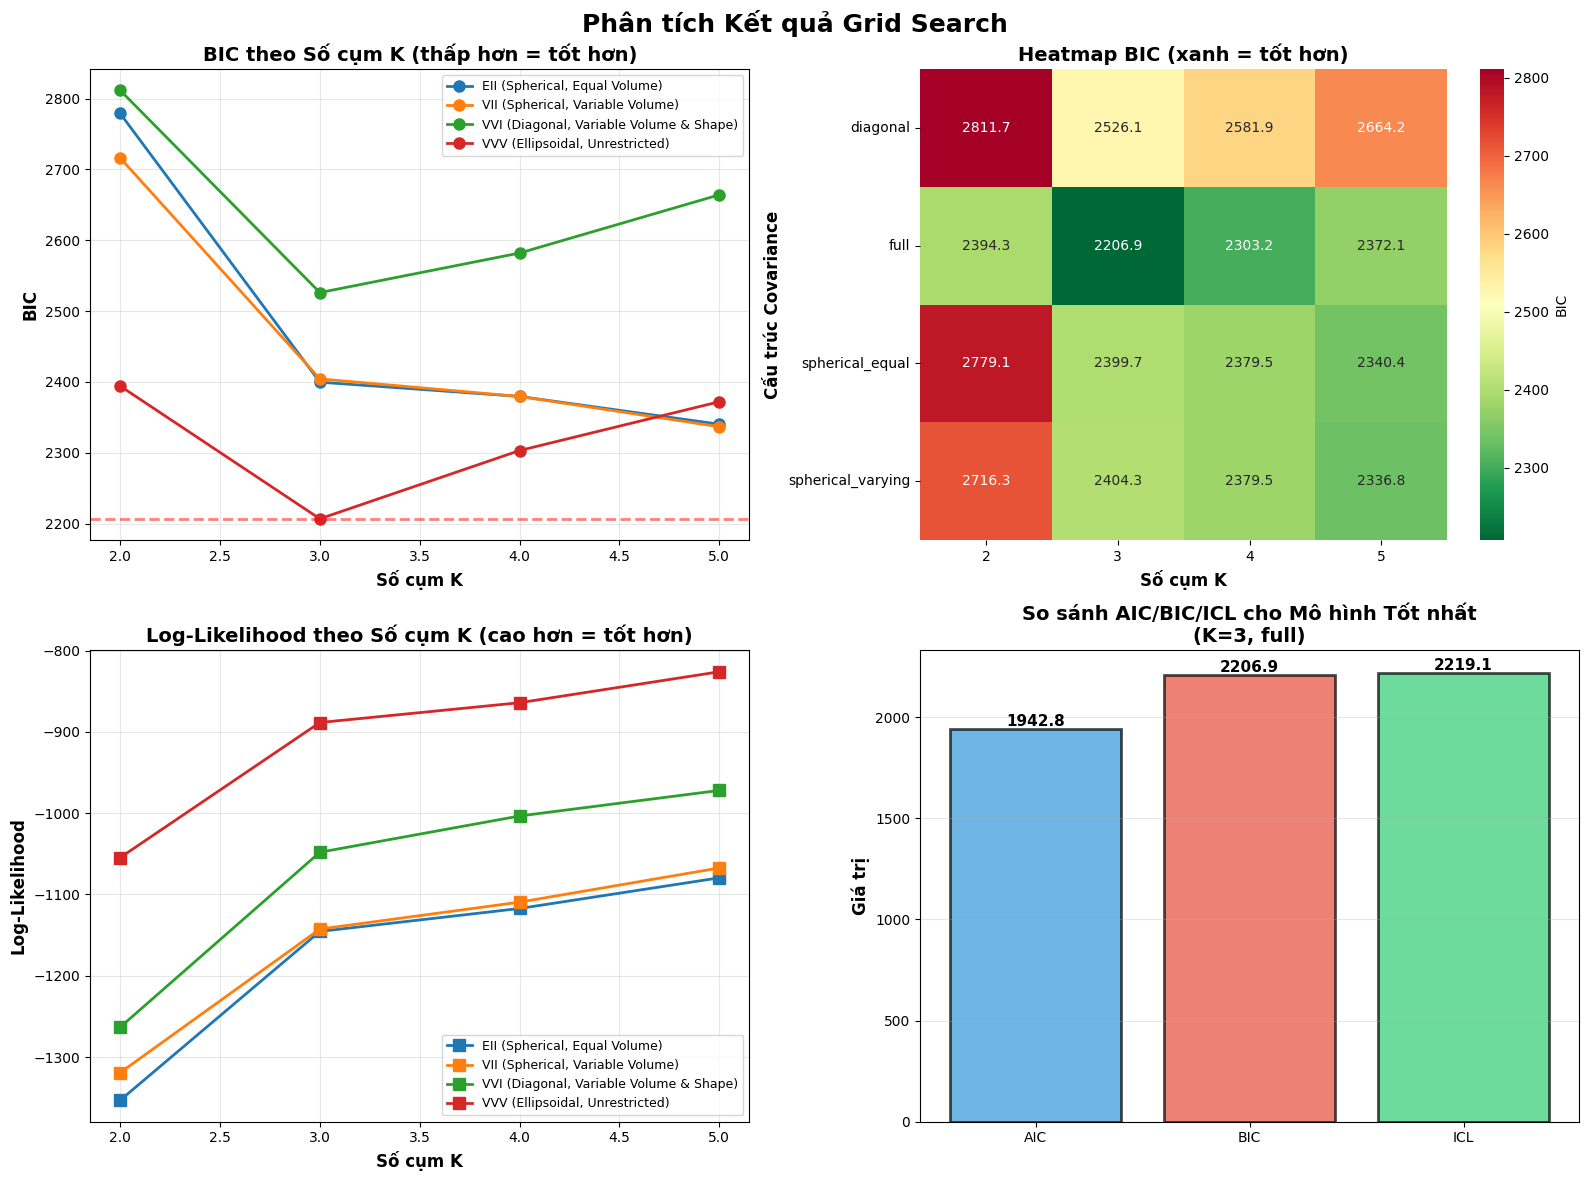


💾 Các biến của mô hình tốt nhất (K=3, Cov='full') đã được lưu để sử dụng ở các bước sau.


In [60]:
# BƯỚC AC: BÁO CÁO, TRỰC QUAN HÓA VÀ LƯU KẾT QUẢ TỐI ƯU

try:
    # --- HIỂN THỊ KẾT QUẢ ---
    print("\n" + "=" * 80)
    print("KẾT QUẢ TỐI ƯU HÓA")
    print("=" * 80)
    
    print("\n📊 Bảng xếp hạng tất cả các mô hình (sắp xếp theo BIC - thấp hơn là tốt hơn):")
    print(results_df[['K', 'Cov_Type', 'BIC', 'AIC', 'ICL', 'Log_Likelihood', 'N_Params']].round(2).to_string(index=False))
    
    best_model = results_df.iloc[0]
    print("\n" + "🏆" * 25)
    print("          MÔ HÌNH TỐI ƯU NHẤT          ")
    print("🏆" * 25)
    print(f"\n✓ Số cụm K: {best_model['K']}")
    print(f"✓ Cấu trúc Covariance: {best_model['Cov_Name']}")
    print(f"✓ BIC: {best_model['BIC']:.4f} (Chỉ số quyết định)")
    
    
    # --- TRỰC QUAN HÓA KẾT QUẢ ---
    print("\n" + "=" * 80)
    print("TRỰC QUAN HÓA KẾT QUẢ LỰA CHỌN MÔ HÌNH")
    print("=" * 80)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Phân tích Kết quả Grid Search', fontsize=18, fontweight='bold')

    # Plot 1: BIC theo K cho từng cov_type
    ax = axes[0, 0]
    for cov_type in cov_types:
        subset = results_df[results_df['Cov_Type'] == cov_type].sort_values('K')
        if len(subset) > 0:
            ax.plot(subset['K'], subset['BIC'], marker='o', linewidth=2, 
                label=covariance_structures[cov_type]['name'], markersize=8)
    ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
    ax.set_ylabel('BIC', fontsize=12, fontweight='bold')
    ax.set_title('BIC theo Số cụm K (thấp hơn = tốt hơn)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=best_model['BIC'], color='red', linestyle='--', linewidth=2, alpha=0.5)

    # Plot 2: Heatmap BIC
    ax = axes[0, 1]
    pivot_bic = results_df.pivot(index='Cov_Type', columns='K', values='BIC')
    sns.heatmap(pivot_bic, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, 
            cbar_kws={'label': 'BIC'})
    ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cấu trúc Covariance', fontsize=12, fontweight='bold')
    ax.set_title('Heatmap BIC (xanh = tốt hơn)', fontsize=14, fontweight='bold')

    # Plot 3: Log-Likelihood theo K
    ax = axes[1, 0]
    for cov_type in cov_types:
        subset = results_df[results_df['Cov_Type'] == cov_type].sort_values('K')
        if len(subset) > 0:
            ax.plot(subset['K'], subset['Log_Likelihood'], marker='s', linewidth=2,
                label=covariance_structures[cov_type]['name'], markersize=8)
    ax.set_xlabel('Số cụm K', fontsize=12, fontweight='bold')
    ax.set_ylabel('Log-Likelihood', fontsize=12, fontweight='bold')
    ax.set_title('Log-Likelihood theo Số cụm K (cao hơn = tốt hơn)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Plot 4: So sánh AIC, BIC, ICL cho mô hình tốt nhất
    ax = axes[1, 1]
    best_K = best_model['K']
    best_cov = best_model['Cov_Type']
    subset_best = results_df[(results_df['K'] == best_K) & (results_df['Cov_Type'] == best_cov)]

    criteria = ['AIC', 'BIC', 'ICL']
    values = [subset_best['AIC'].values[0], subset_best['BIC'].values[0], subset_best['ICL'].values[0]]
    colors_bar = ['#3498db', '#e74c3c', '#2ecc71']
    bars = ax.bar(criteria, values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)

    # Thêm giá trị lên bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Giá trị', fontsize=12, fontweight='bold')
    ax.set_title(f'So sánh AIC/BIC/ICL cho Mô hình Tốt nhất\n(K={best_K}, {best_cov})', 
             fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # --- LƯU KẾT QUẢ TỐI ƯU ĐỂ DÙNG SAU ---
    optimal_K = int(best_model['K'])
    optimal_cov_type = best_model['Cov_Type']
    optimal_P, optimal_mu, optimal_sigma, optimal_gamma = best_model['Model']
    
    print(f"\n💾 Các biến của mô hình tốt nhất (K={optimal_K}, Cov='{optimal_cov_type}') đã được lưu để sử dụng ở các bước sau.")
    
except NameError:
    print("\n❌ LỖI: DataFrame 'results_df' không tồn tại. Vui lòng chạy cell Grid Search (7A) trước.")

In [61]:
# BƯỚC AD: TỐI ƯU HÓA NGHIỆM VỚI K-MEANS++ & MULTIPLE RESTARTS


# Mục tiêu: Với mô hình tốt nhất đã chọn (K và cov_type), chạy lại EM nhiều lần
# với điểm khởi tạo thông minh hơn (K-Means++) để tìm ra nghiệm có
# log-likelihood cao hơn, tăng khả năng tìm thấy cực đại toàn cục.

print(" TỐI ƯU HÓA NGHIỆM VỚI K-MEANS++ & MULTIPLE RESTARTS")


#  ĐỊNH NGHĨA HÀM KHỞI TẠO BẰNG K-MEANS++
def initialize_with_kmeans(X, K, n_init=10, random_state=0):
    """
    Khởi tạo tham số GMM (p_k, mu, Sigma) bằng kết quả của K-Means++.
    """
    km = KMeans(n_clusters=K, n_init=n_init, init='k-means++', random_state=random_state)
    labels = km.fit_predict(X)
    mu_init = km.cluster_centers_
    
    N_k = np.bincount(labels, minlength=K).astype(float)
    p_k_init = N_k / X.shape[0]
    
    Sigma_init = []
    for k in range(K):
        points_in_cluster = X[labels == k]
        if len(points_in_cluster) <= X.shape[1]: # Điều kiện an toàn hơn
            Sigma_init.append(np.eye(X.shape[1]) * 1e-3)
        else:
            S = np.cov(points_in_cluster.T) + 1e-3 * np.eye(X.shape[1])
            Sigma_init.append(S)
            
    return p_k_init, mu_init, Sigma_init

# ĐỊNH NGHĨA HÀM CHẠY EM VỚI THAM SỐ CHO TRƯỚC 
# Ghi chú: Hàm này gần giống em_with_cov_structure nhưng được thiết kế để
# nhận vào tham số khởi tạo, thay vì tự khởi tạo bên trong.
def run_em_from_initialization(X, p_k_init, mu_init, Sigma_init, cov_type, tol=1e-6, max_iter=200):
    """
    Chạy thuật toán EM với một bộ tham số khởi tạo cụ thể.
    TÁI SỬ DỤNG các hàm e_step_logspace và m_step_with_constraint đã định nghĩa.
    """
    p_k, mu, Sigma = p_k_init.copy(), mu_init.copy(), [s.copy() for s in Sigma_init]
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        # E-STEP (Tái sử dụng hàm đã có)
        gamma, log_L, _ = e_step_logspace(X, mu, Sigma, p_k)
        
        if iteration > 0 and abs(log_L - prev_log_L) < tol:
            break
        
        if log_L < prev_log_L - 1e-6:
            warnings.warn(f"Log-likelihood giảm tại iter {iteration}: {prev_log_L:.4f} -> {log_L:.4f}")

        prev_log_L = log_L
        
        # M-STEP (Tái sử dụng hàm đã có)
        p_k, mu, Sigma = m_step_with_constraint(X, gamma, cov_type=cov_type)
    
    return p_k, mu, Sigma, prev_log_L # Trả về log_L cuối cùng trước khi break

# Hàm relabelling (giữ nguyên)
def relabel_by_prior(p_k, mu, Sigma):
    idx = np.argsort(p_k)[::-1]
    return p_k[idx], mu[idx], [Sigma[i] for i in idx]


# --- 2. THỰC HIỆN QUÁ TRÌNH MULTIPLE RESTARTS ---
# Giả sử optimal_K và optimal_cov_type đã được lưu từ cell Grid Search.
try:
    print("\nSử dụng thông tin từ mô hình tối ưu đã tìm thấy ở Grid Search:")
    print(f"  • Số cụm tối ưu (K): {optimal_K}")
    print(f"  • Cấu trúc covariance tối ưu: '{optimal_cov_type}'")

    n_restarts = 10
    print(f"\n🔄 Bắt đầu chạy {n_restarts} lần restart với khởi tạo K-Means++...")

    best_ll_restart = -np.inf
    best_params_restart = None
    best_seed_restart = -1
    restart_results_list = []

    for seed in range(n_restarts):
        # 1. Khởi tạo bằng K-Means++
        p_k_init, mu_init, Sigma_init = initialize_with_kmeans(X, optimal_K, n_init=1, random_state=seed)
        
        # 2. Chạy EM từ điểm khởi tạo này
        p_k_est, mu_est, Sigma_est, ll = run_em_from_initialization(
            X, p_k_init, mu_init, Sigma_init, 
            cov_type=optimal_cov_type
        )
        
        restart_results_list.append({'seed': seed, 'log_likelihood': ll})
        print(f"  - Restart {seed+1}/{n_restarts} (seed={seed}): Log-likelihood = {ll:.4f}")
        
        # 3. Lưu lại kết quả tốt nhất
        if ll > best_ll_restart:
            best_ll_restart = ll
            best_params_restart = (p_k_est, mu_est, Sigma_est)
            best_seed_restart = seed

    # --- 3. XỬ LÝ KẾT QUẢ TỐT NHẤT ---
    # Lấy ra các tham số tốt nhất
    best_p_k, best_mu, best_Sigma = best_params_restart

    # Sắp xếp lại nhãn để kết quả nhất quán
    best_p_k, best_mu, best_Sigma = relabel_by_prior(best_p_k, best_mu, best_Sigma)

    print(f"\n\n✓✓✓ HOÀN THÀNH QUÁ TRÌNH TÍNH TOÁN MULTIPLE RESTARTS.")
    print("Các tham số tối ưu (best_p_k, best_mu, best_Sigma) đã được lưu.")

except NameError:
    print("\n❌ LỖI: Không tìm thấy biến `optimal_K`. Vui lòng chạy cell Grid Search trước.")

 TỐI ƯU HÓA NGHIỆM VỚI K-MEANS++ & MULTIPLE RESTARTS

Sử dụng thông tin từ mô hình tối ưu đã tìm thấy ở Grid Search:
  • Số cụm tối ưu (K): 3
  • Cấu trúc covariance tối ưu: 'full'

🔄 Bắt đầu chạy 10 lần restart với khởi tạo K-Means++...
  - Restart 1/10 (seed=0): Log-likelihood = -888.4125
  - Restart 2/10 (seed=1): Log-likelihood = -888.3887
  - Restart 3/10 (seed=2): Log-likelihood = -899.7218
  - Restart 4/10 (seed=3): Log-likelihood = -899.7218
  - Restart 5/10 (seed=4): Log-likelihood = -888.4125
  - Restart 6/10 (seed=5): Log-likelihood = -899.7218
  - Restart 7/10 (seed=6): Log-likelihood = -899.7218
  - Restart 8/10 (seed=7): Log-likelihood = -888.3887
  - Restart 9/10 (seed=8): Log-likelihood = -888.4125
  - Restart 10/10 (seed=9): Log-likelihood = -899.7218


✓✓✓ HOÀN THÀNH QUÁ TRÌNH TÍNH TOÁN MULTIPLE RESTARTS.
Các tham số tối ưu (best_p_k, best_mu, best_Sigma) đã được lưu.



KẾT QUẢ TỐI ƯU SAU KHI CHẠY MULTIPLE RESTARTS

🏆 Kết quả tốt nhất tìm được:
  • Từ seed khởi tạo: 7
  • Log-likelihood cao nhất: -888.388731
  • Log-likelihood từ Grid Search: -888.388802
  => Cải thiện: +0.000071

TRỰC QUAN HÓA SO SÁNH CÁC LẦN RESTART


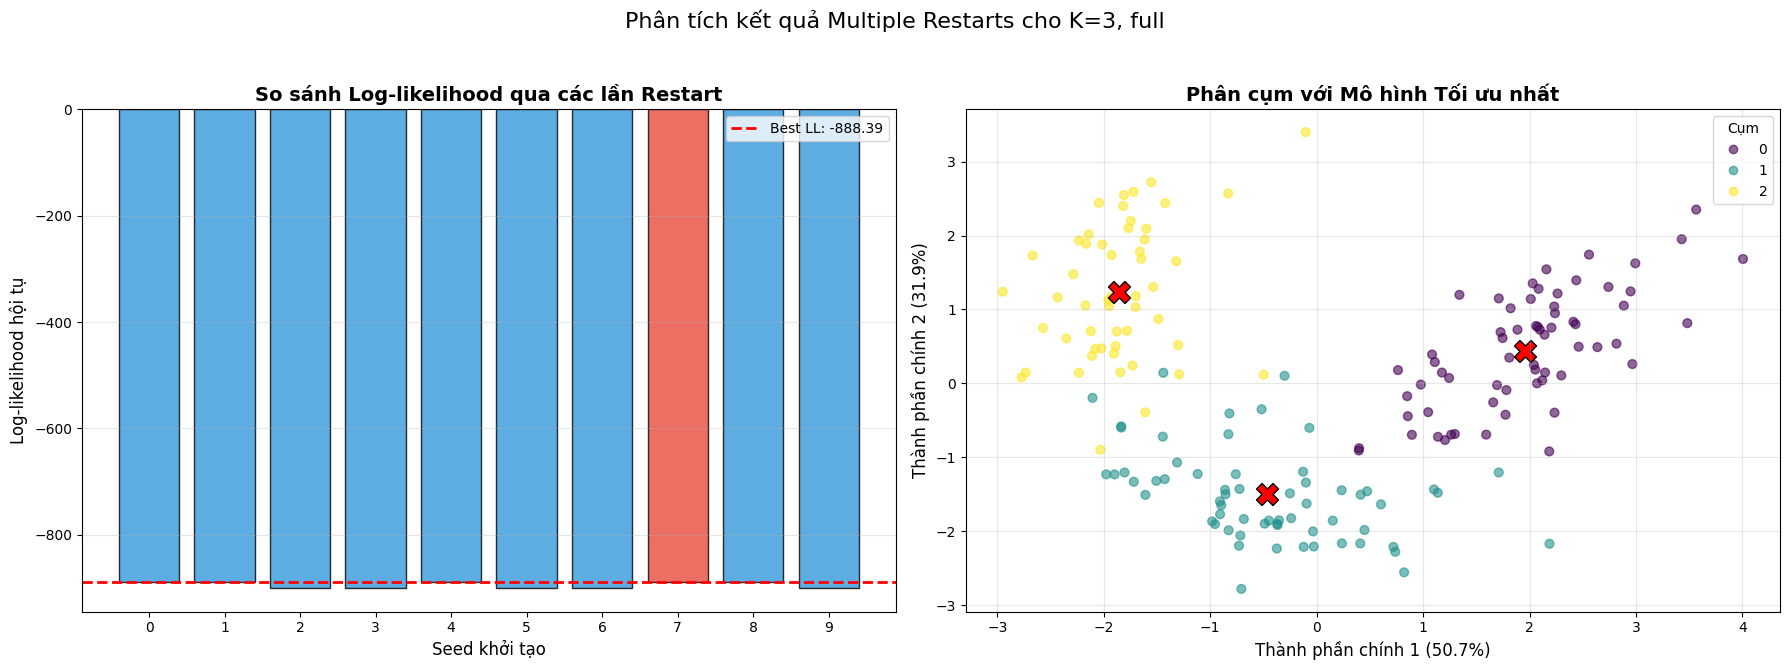

In [62]:
# BƯỚC AE: TRỰC QUAN HÓA VÀ SO SÁNH KẾT QUẢ MULTIPLE RESTARTS


try:
    # --- 1. BÁO CÁO TÓM TẮT KẾT QUẢ ---
    print("\n" + "=" * 80)
    print("KẾT QUẢ TỐI ƯU SAU KHI CHẠY MULTIPLE RESTARTS")
    print("=" * 80)

    print(f"\n🏆 Kết quả tốt nhất tìm được:")
    print(f"  • Từ seed khởi tạo: {best_seed_restart}")
    print(f"  • Log-likelihood cao nhất: {best_ll_restart:.6f}")

    # So sánh với kết quả từ Grid Search
    original_best_ll = results_df.loc[results_df['BIC'].idxmin()]['Log_Likelihood']
    print(f"  • Log-likelihood từ Grid Search: {original_best_ll:.6f}")
    if best_ll_restart > original_best_ll:
        print(f"  => Cải thiện: +{best_ll_restart - original_best_ll:.6f}")
    else:
        print("  => Không tìm thấy nghiệm tốt hơn so với lần chạy duy nhất trong Grid Search.")


    # --- 2. TRỰC QUAN HÓA ---
    print("\n" + "=" * 80)
    print("TRỰC QUAN HÓA SO SÁNH CÁC LẦN RESTART")
    print("=" * 80)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Phân tích kết quả Multiple Restarts cho K={optimal_K}, {optimal_cov_type}', fontsize=16)

    # Plot 1: Log-likelihood của các restarts
    ax = axes[0]
    seeds = [r['seed'] for r in restart_results_list]
    lls = [r['log_likelihood'] for r in restart_results_list]
    colors = ['#e74c3c' if i == best_seed_restart else '#3498db' for i in seeds] # Đỏ cho best, xanh cho còn lại
    
    bars = ax.bar(seeds, lls, color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(y=best_ll_restart, color='red', linestyle='--', linewidth=2, label=f'Best LL: {best_ll_restart:.2f}')
    
    ax.set_xlabel('Seed khởi tạo', fontsize=12)
    ax.set_ylabel('Log-likelihood hội tụ', fontsize=12)
    ax.set_title('So sánh Log-likelihood qua các lần Restart', fontsize=14, fontweight='bold')
    ax.set_xticks(seeds)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    # Plot 2: Phân cụm với mô hình tốt nhất (PCA 2D)
    ax = axes[1]
    # Gán nhãn cho dữ liệu dựa trên mô hình tốt nhất
    best_gamma, _, _ = e_step_logspace(X, best_mu, best_Sigma, best_p_k)
    best_labels = np.argmax(best_gamma, axis=1)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    mu_pca = pca.transform(best_mu)

    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='viridis', alpha=0.6, s=40)
    ax.scatter(mu_pca[:, 0], mu_pca[:, 1], c='red', marker='X', s=250, edgecolors='black', label='Tâm cụm')
    
    ax.set_xlabel(f'Thành phần chính 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
    ax.set_ylabel(f'Thành phần chính 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
    ax.set_title('Phân cụm với Mô hình Tối ưu nhất', fontsize=14, fontweight='bold')
    ax.legend(*scatter.legend_elements(), title='Cụm')
    ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except NameError as e:
    print(f"\n❌ LỖI: Không tìm thấy biến cần thiết: {e}. Vui lòng chạy cell tính toán (8A) trước.")

TA THẤY RẰNG , NẾU MULTI START CHỈ XẢY RA Ở PHẦN SAU KHI CHỌN ĐƯỢC MÔ HÌNH TỐI ƯU THÌ KHÔNG ĐÚNG VỀ MẶT QUY TRÌNH THỰC HIỆN, VẬY NÊN TA SẼ THỰC HIỆN NGAY TỪ PHẦN CHẠY THUẬT TOÁN EM ĐỂ ĐẢM BẢO TÍNH CÔNG BẰNG

In [63]:
 # BƯỚC BA: NÂNG CẤP HÀM EM ĐỂ HỖ TRỢ MULTI-START

def em_with_random_state(X, K, cov_type='full', max_iter=150, tol=1e-4, random_state=42):
    """
    Phiên bản nâng cấp của thuật toán EM, cho phép truyền vào random_state
    để đảm bảo các lần khởi tạo khác nhau trong multi-start.
    """
    N, p = X.shape
    # Sử dụng random_state được truyền vào
    np.random.seed(random_state)
    
    # Phần khởi tạo và vòng lặp giữ nguyên như hàm em_with_cov_structure
    P = np.ones(K) / K
    random_idx = np.random.choice(N, K, replace=False)
    mu = X[random_idx]
    
    # Khởi tạo covariance theo cấu trúc
    if cov_type == 'spherical_equal' or cov_type == 'spherical_varying':
        sigma = [np.eye(p) * np.var(X) for _ in range(K)]
    elif cov_type == 'diagonal':
        sigma = [np.diag(np.var(X, axis=0)) for _ in range(K)]
    else: # full
        sigma = [np.cov(X.T) + np.eye(p) * 1e-3 for _ in range(K)]
    
    prev_log_L = -np.inf
    
    for iteration in range(max_iter):
        gamma, log_L, _ = e_step_logspace(X, mu, sigma, P)
        
        if iteration > 0 and abs(log_L - prev_log_L) < tol:
            break
        prev_log_L = log_L
        
        P, mu, sigma = m_step_with_constraint(X, gamma, cov_type=cov_type)
    
    # Trả về tất cả các tham số cần thiết cho việc đánh giá
    return P, mu, sigma, gamma, prev_log_L

print("✓ Hàm em_with_random_state đã được định nghĩa để hỗ trợ multi-start.")

✓ Hàm em_with_random_state đã được định nghĩa để hỗ trợ multi-start.


In [64]:
# BB GRID SEARCH NÂNG CAO VỚI MULTI-START

# --- Cấu hình Grid Search ---
K_range = range(2, 6)
cov_types = ['spherical_equal', 'spherical_varying', 'diagonal', 'full']
n_restarts = 20  # Số lần chạy lại cho mỗi mô hình

multi_start_results = []
N, p = X.shape

print("\n" + "=" * 80)
print("BẮT ĐẦU GRID SEARCH NÂNG CAO VỚI MULTI-START")
print("=" * 80)
print(f"• Số cụm K: {list(K_range)}")
print(f"• Cấu trúc covariance: {len(cov_types)} loại")
print(f"• Số lần chạy lại cho mỗi mô hình: {n_restarts}")
print(f"• Tổng số lần chạy EM: {len(K_range) * len(cov_types) * n_restarts}")

start_time = time.time()
# --- Vòng lặp chính ---
for K in K_range:
    for cov_type in cov_types:
        
        best_run_ll = -np.inf
        best_run_params = None
        
        # --- Vòng lặp Multi-start bên trong ---
        for i in range(n_restarts):
            P, mu, sigma, gamma, log_L = em_with_random_state(
                X, K, cov_type=cov_type, random_state=i
            )
            
            if log_L > best_run_ll:
                best_run_ll = log_L
                best_run_params = (P, mu, sigma, gamma)
        
        # Lấy ra kết quả tốt nhất
        P_best, mu_best, sigma_best, _ = best_run_params # Tạm thời bỏ qua gamma cũ
        
        # Sắp xếp lại các tham số để đảm bảo tính nhất quán
        P_best, mu_best, sigma_best = relabel_by_weight(P_best, mu_best, sigma_best)
        
        # --- THAY ĐỔI QUAN TRỌNG ---
        # Tính lại gamma một lần nữa với bộ tham số đã được sắp xếp lại
        # để đảm bảo ICL được tính toán một cách chính xác.
        gamma_best, _, _ = e_step_logspace(X, mu_best, sigma_best, P_best)
        # ---------------------------

        # Tính toán các chỉ số dựa trên kết quả tốt nhất và nhất quán
        n_params = count_parameters(K, p, cov_type)
        aic, bic, icl = compute_aic_bic_icl(best_run_ll, N, n_params, gamma_best)
        
        # Lưu kết quả "vô địch" của mô hình này
        multi_start_results.append({
            'K': K,
            'Cov_Type': cov_type,
            'Log_Likelihood': best_run_ll,
            'N_Params': n_params,
            'AIC': aic,
            'BIC': bic,
            'ICL': icl
            # Không cần lưu Model nữa để tiết kiệm bộ nhớ
        })
        print(f"✓ Hoàn thành K={K}, cov='{cov_type}': BIC tốt nhất = {bic:.2f} (từ LogL={best_run_ll:.2f})")

print(f"\n✓ Hoàn thành Grid Search nâng cao sau {time.time() - start_time:.2f} giây.")

# --- Chuyển đổi sang DataFrame ---
results_ms_df = pd.DataFrame(multi_start_results)




BẮT ĐẦU GRID SEARCH NÂNG CAO VỚI MULTI-START
• Số cụm K: [2, 3, 4, 5]
• Cấu trúc covariance: 4 loại
• Số lần chạy lại cho mỗi mô hình: 20
• Tổng số lần chạy EM: 320
✓ Hoàn thành K=2, cov='spherical_equal': BIC tốt nhất = 2779.08 (từ LogL=-1353.27)
✓ Hoàn thành K=2, cov='spherical_varying': BIC tốt nhất = 2716.33 (từ LogL=-1319.30)
✓ Hoàn thành K=2, cov='diagonal': BIC tốt nhất = 2760.17 (từ LogL=-1237.58)
✓ Hoàn thành K=2, cov='full': BIC tốt nhất = 2209.05 (từ LogL=-962.03)
✓ Hoàn thành K=3, cov='spherical_equal': BIC tốt nhất = 2399.71 (từ LogL=-1145.45)
✓ Hoàn thành K=3, cov='spherical_varying': BIC tốt nhất = 2404.34 (từ LogL=-1142.58)
✓ Hoàn thành K=3, cov='diagonal': BIC tốt nhất = 2523.58 (từ LogL=-1046.75)
✓ Hoàn thành K=3, cov='full': BIC tốt nhất = 2206.87 (từ LogL=-888.39)
✓ Hoàn thành K=4, cov='spherical_equal': BIC tốt nhất = 2332.13 (từ LogL=-1093.52)
✓ Hoàn thành K=4, cov='spherical_varying': BIC tốt nhất = 2342.81 (từ LogL=-1091.09)
✓ Hoàn thành K=4, cov='diagonal': BI

In [65]:
# ============================================================
# BƯỚC 11: BÁO CÁO TOÀN DIỆN KẾT QUẢ 
# ============================================================
import pandas as pd
from IPython.display import display, Markdown

# Hàm hỗ trợ định dạng số cho đẹp
def format_float(x):
    return "{:,.2f}".format(x)

try:
    # --- 1. BẢNG TỔNG HỢP CÁC "NHÀ VÔ ĐỊCH" ---
    print("\n" + "=" * 80)
    print("             BÁO CÁO KẾT QUẢ TỐI ƯU HÓA (GRID SEARCH + MULTI-START)")
    print("=" * 80)

    # Tìm mô hình tốt nhất theo từng chỉ số
    best_bic_idx = results_ms_df['BIC'].idxmin()
    best_aic_idx = results_ms_df['AIC'].idxmin()
    best_icl_idx = results_ms_df['ICL'].idxmin()
    
    # Tạo bảng so sánh
    comparison_data = []
    for criterion, idx in [('BIC', best_bic_idx), ('AIC', best_aic_idx), ('ICL', best_icl_idx)]:
        row = results_ms_df.loc[idx]
        comparison_data.append({
            'Tiêu chí (Tốt nhất)': criterion,
            'Số cụm (K)': int(row['K']),
            'Cấu trúc Cov': row['Cov_Type'],
            'Giá trị': row[criterion],
            'Log-Likelihood': row['Log_Likelihood']
        })
    
    comp_df = pd.DataFrame(comparison_data)
    
    # Định dạng số trực tiếp (thay vì dùng .style)
    comp_df['Giá trị'] = comp_df['Giá trị'].apply(format_float)
    comp_df['Log-Likelihood'] = comp_df['Log-Likelihood'].apply(format_float)
    
    display(Markdown("### 🏆 BẢNG TỔNG HỢP MÔ HÌNH TỐT NHẤT"))
    display(comp_df)
    
    print("-" * 80)
    print("Ghi chú:")
    print("  - BIC: Cân bằng tốt nhất (Khuyên dùng cho phân cụm).")
    print("  - ICL: Phạt nặng các cụm chồng lấn (Ưu tiên cụm tách biệt).")
    print("-" * 80)

    # --- 2. BẢNG XẾP HẠNG CHI TIẾT (TOP 5 THEO BIC) ---
    display(Markdown("### 📊 TOP 5 MÔ HÌNH TỐT NHẤT (Theo BIC)"))
    
    # Sắp xếp và lấy Top 5
    top5_bic = results_ms_df.sort_values('BIC', ascending=True).head(5).copy()
    
    # Chọn cột hiển thị
    cols_to_show = ['K', 'Cov_Type', 'BIC', 'AIC', 'ICL', 'Log_Likelihood', 'N_Params']
    top5_display = top5_bic[cols_to_show].copy()
    
    # Định dạng số liệu
    for col in ['BIC', 'AIC', 'ICL', 'Log_Likelihood']:
        top5_display[col] = top5_display[col].apply(format_float)
        
    display(top5_display)

    # --- 3. LƯU MÔ HÌNH TỐI ƯU (FINAL SELECTION) ---
    # Mặc định chọn theo BIC
    final_best_model = results_ms_df.loc[best_bic_idx]
    
    optimal_K = int(final_best_model['K'])
    optimal_cov_type = final_best_model['Cov_Type']
    
    print("\n" + "=" * 80)
    print("✅ QUYẾT ĐỊNH CUỐI CÙNG (Dựa trên BIC)")
    print(f"  • Số cụm tối ưu (K): {optimal_K}")
    print(f"  • Cấu trúc Hiệp phương sai: '{optimal_cov_type}'")
    print(f"  • BIC: {final_best_model['BIC']:.2f}")
    print("=" * 80)
    
    # Lưu lại các tham số mô hình để dùng cho bước Visualize sau này
    # (Giả sử bạn đã lưu tuple params trong cột 'Params' hoặc tương tự khi chạy Grid Search)
    # Nếu chưa lưu, bạn sẽ cần chạy lại hàm EM một lần nữa với tham số tối ưu này ở cell sau.

except NameError:
    print("\n❌ LỖI: Không tìm thấy biến 'results_ms_df'. Hãy chắc chắn bạn đã chạy xong bước Grid Search.")
except Exception as e:
    print(f"\n❌ LỖI KHÔNG MONG MUỐN: {str(e)}")


             BÁO CÁO KẾT QUẢ TỐI ƯU HÓA (GRID SEARCH + MULTI-START)


### 🏆 BẢNG TỔNG HỢP MÔ HÌNH TỐT NHẤT

,Tiêu chí (Tốt nhất),Số cụm (K),Cấu trúc Cov,Giá trị,Log-Likelihood
0,BIC,3,full,"2,206.87",-888.39
1,AIC,5,full,"1,893.10",-807.55
2,ICL,2,full,"2,211.11",-962.03


--------------------------------------------------------------------------------
Ghi chú:
  - BIC: Cân bằng tốt nhất (Khuyên dùng cho phân cụm).
  - ICL: Phạt nặng các cụm chồng lấn (Ưu tiên cụm tách biệt).
--------------------------------------------------------------------------------


### 📊 TOP 5 MÔ HÌNH TỐT NHẤT (Theo BIC)

,K,Cov_Type,BIC,AIC,ICL,Log_Likelihood,N_Params
7,3,full,"2,206.87","1,942.78","2,219.16",-888.39,83
3,2,full,"2,209.05","2,034.05","2,211.11",-962.03,55
11,4,full,"2,265.35","1,912.17","2,278.98",-845.08,111
12,5,spherical_equal,"2,298.03","2,186.67","2,346.94","-1,058.33",35
13,5,spherical_varying,"2,304.69","2,180.60","2,355.14","-1,051.30",39



✅ QUYẾT ĐỊNH CUỐI CÙNG (Dựa trên BIC)
  • Số cụm tối ưu (K): 3
  • Cấu trúc Hiệp phương sai: 'full'
  • BIC: 2206.87



BẮT ĐẦU ĐÁNH GIÁ ĐỘ ỔN ĐỊNH CỦA MÔ HÌNH TỐI ƯU
  - Đang tạo nhãn tham chiếu trên toàn bộ dữ liệu...
  - Đang xử lý mẫu bootstrap thứ 10/50...
  - Đang xử lý mẫu bootstrap thứ 20/50...
  - Đang xử lý mẫu bootstrap thứ 30/50...
  - Đang xử lý mẫu bootstrap thứ 40/50...
  - Đang xử lý mẫu bootstrap thứ 50/50...

--------------------------------------------------------------------------------
KẾT QUẢ ĐÁNH GIÁ ĐỘ ỔN ĐỊNH
--------------------------------------------------------------------------------
  Số mẫu bootstrap thành công: 50 / 50

  Silhouette Score (Đo độ chặt chẽ của cụm):
    - Trung bình: 0.270
    - Độ lệch chuẩn: 0.084

  Adjusted Rand Index (ARI) (Đo độ tương đồng với kết quả gốc):
    - Trung bình: 0.552 (Càng gần 1.0 càng ổn định)
    - Độ lệch chuẩn: 0.192 (Càng nhỏ càng ổn định)


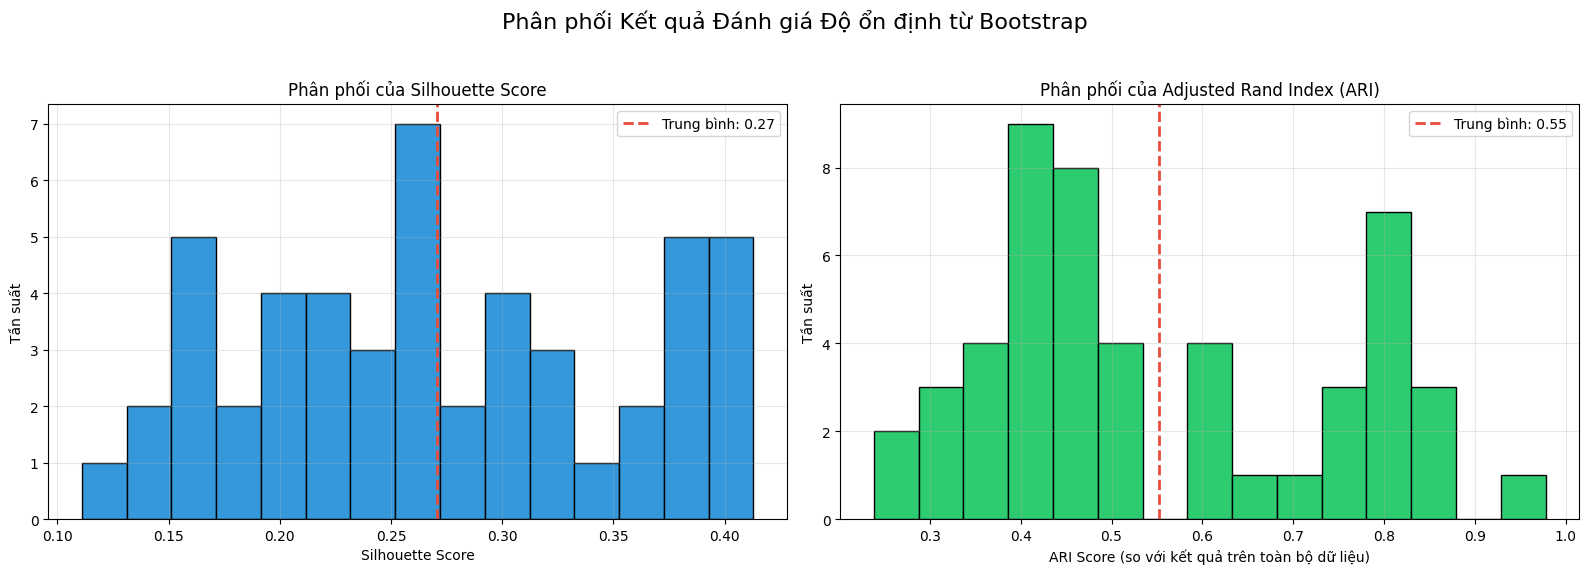

In [66]:
# BƯỚC 12: ĐÁNH GIÁ ĐỘ ỔN ĐỊNH CỦA MÔ HÌNH TỐI ƯU BẰNG BOOTSTRAP


from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.utils import resample

#  ĐỊNH NGHĨA HÀM BOOTSTRAP CHÍNH 

def evaluate_stability_with_bootstrap(X, model_runner_fn, n_bootstraps=50, sample_fraction=0.8, random_state=42):
    """
    Thực hiện Bootstrap để đánh giá độ ổn định của một thuật toán phân cụm.
        
    Returns:
        dict: Chứa kết quả thống kê của Silhouette và ARI.
    """
    rng = np.random.RandomState(random_state)
    n_samples = X.shape[0]
    silhouette_scores = []
    ari_scores = []

    # Chạy mô hình trên toàn bộ dữ liệu một lần để có nhãn tham chiếu
    print("  - Đang tạo nhãn tham chiếu trên toàn bộ dữ liệu...")
    reference_labels = model_runner_fn(X)
    
    # Bắt đầu vòng lặp bootstrap
    for i in range(n_bootstraps):
        if (i + 1) % 10 == 0:
            print(f"  - Đang xử lý mẫu bootstrap thứ {i+1}/{n_bootstraps}...")
        
        # Tạo mẫu bootstrap
        indices = rng.choice(n_samples, size=int(n_samples * sample_fraction), replace=True)
        X_bootstrap = X[indices]
        
        # Chạy mô hình trên mẫu bootstrap
        bootstrap_labels = model_runner_fn(X_bootstrap)
        
        # Tính Silhouette Score (chỉ trên mẫu bootstrap)
        # Bỏ qua nếu chỉ có 1 cụm được tìm thấy
        if len(np.unique(bootstrap_labels)) > 1:
            try:
                score = silhouette_score(X_bootstrap, bootstrap_labels)
                silhouette_scores.append(score)
            except Exception:
                silhouette_scores.append(np.nan)
        else:
            silhouette_scores.append(np.nan)
        
        # Tính Adjusted Rand Index (ARI) so với nhãn tham chiếu
        # Chỉ so sánh trên các điểm dữ liệu chung
        reference_labels_subset = reference_labels[indices]
        try:
            ari = adjusted_rand_score(reference_labels_subset, bootstrap_labels)
            ari_scores.append(ari)
        except Exception:
            ari_scores.append(np.nan)

    return {
        'silhouette_scores': np.array(silhouette_scores),
        'ari_scores': np.array(ari_scores)
    }

# --- 12.2. TẠO HÀM "RUNNER" CHO MÔ HÌNH TỐI ƯU ---

# Giả sử các biến sau đã được lưu từ các cell trước:
# - optimal_K, optimal_cov_type
# - em_with_random_state (hàm EM nâng cao)
def run_optimal_gmm(X_subset):
    """
    Chạy mô hình GMM tối ưu (với K và cov_type đã chọn) trên một tập dữ liệu con
    và trả về nhãn cụm (hard labels).
    """
    # Sử dụng multi-start nhỏ (ví dụ 3 lần) cho mỗi lần chạy bootstrap để tăng độ ổn định
    best_ll = -np.inf
    best_gamma = None
    for i in range(3): 
        _, _, _, gamma, ll = em_with_random_state(
            X_subset, 
            K=optimal_K, 
            cov_type=optimal_cov_type,
            random_state=i # Dùng seed cố định để nhất quán
        )
        if ll > best_ll:
            best_ll = ll
            best_gamma = gamma
            
    if best_gamma is None:
        return np.zeros(X_subset.shape[0]) # Trả về mảng 0 nếu có lỗi
        
    return np.argmax(best_gamma, axis=1)


# --- 12.3. CHẠY QUÁ TRÌNH ĐÁNH GIÁ VÀ TRỰC QUAN HÓA ---
print("\n" + "=" * 80)
print("BẮT ĐẦU ĐÁNH GIÁ ĐỘ ỔN ĐỊNH CỦA MÔ HÌNH TỐI ƯU")
print("=" * 80)
try:
    # Bắt đầu quá trình bootstrap
    bootstrap_results = evaluate_stability_with_bootstrap(X, run_optimal_gmm, n_bootstraps=50)

    # Lọc bỏ các giá trị NaN có thể xảy ra
    valid_silhouettes = bootstrap_results['silhouette_scores'][~np.isnan(bootstrap_results['silhouette_scores'])]
    valid_aris = bootstrap_results['ari_scores'][~np.isnan(bootstrap_results['ari_scores'])]

    # --- Báo cáo kết quả ---
    print("\n" + "-" * 80)
    print("KẾT QUẢ ĐÁNH GIÁ ĐỘ ỔN ĐỊNH")
    print("-" * 80)
    print(f"  Số mẫu bootstrap thành công: {len(valid_silhouettes)} / 50")
    print("\n  Silhouette Score (Đo độ chặt chẽ của cụm):")
    print(f"    - Trung bình: {np.mean(valid_silhouettes):.3f}")
    print(f"    - Độ lệch chuẩn: {np.std(valid_silhouettes):.3f}")
    
    print("\n  Adjusted Rand Index (ARI) (Đo độ tương đồng với kết quả gốc):")
    print(f"    - Trung bình: {np.mean(valid_aris):.3f} (Càng gần 1.0 càng ổn định)")
    print(f"    - Độ lệch chuẩn: {np.std(valid_aris):.3f} (Càng nhỏ càng ổn định)")

    # --- Trực quan hóa ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Phân phối Kết quả Đánh giá Độ ổn định từ Bootstrap', fontsize=16)

    # Biểu đồ phân phối Silhouette Score
    axes[0].hist(valid_silhouettes, bins=15, color='#3498db', edgecolor='black')
    axes[0].axvline(np.mean(valid_silhouettes), color='#e74c3c', linestyle='--', linewidth=2, label=f'Trung bình: {np.mean(valid_silhouettes):.2f}')
    axes[0].set_title('Phân phối của Silhouette Score')
    axes[0].set_xlabel('Silhouette Score')
    axes[0].set_ylabel('Tần suất')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Biểu đồ phân phối ARI
    axes[1].hist(valid_aris, bins=15, color='#2ecc71', edgecolor='black')
    axes[1].axvline(np.mean(valid_aris), color='#e74c3c', linestyle='--', linewidth=2, label=f'Trung bình: {np.mean(valid_aris):.2f}')
    axes[1].set_title('Phân phối của Adjusted Rand Index (ARI)')
    axes[1].set_xlabel('ARI Score (so với kết quả trên toàn bộ dữ liệu)')
    axes[1].set_ylabel('Tần suất')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except NameError:
    print("\n❌ LỖI: Không tìm thấy biến `optimal_K`. Vui lòng chạy cell Grid Search trước để xác định mô hình tối ưu.")